In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import chi2_contingency, pointbiserialr, f_oneway
from statsmodels.stats.outliers_influence import variance_inflation_factor

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [17]:
notebook_dir = os.getcwd()
path = os.path.join(notebook_dir, '..', 'data', 'processed', 'stroke_processed.csv')
stroke_processed_data = pd.read_csv(path)

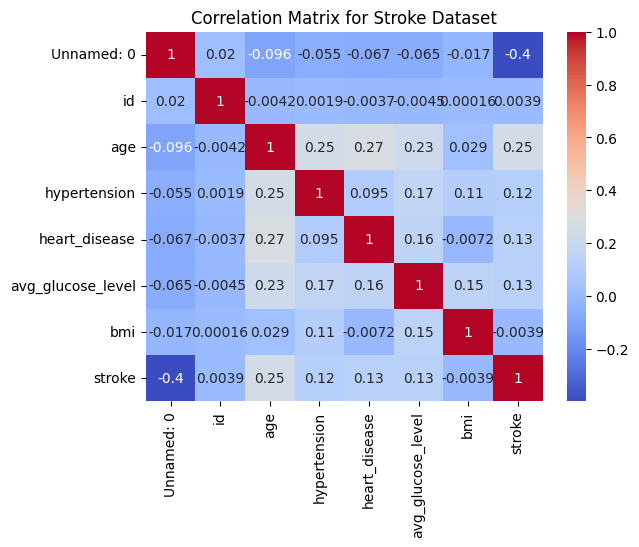

In [4]:
correlation_matrix = stroke_processed_data.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix for Stroke Dataset')
plt.show()

In [6]:
# Chi-Square Test: Categorical vs Categorical
# Example: Gender vs Stroke
print("=" * 50)
print("CHI-SQUARE TEST: Categorical vs Categorical")
print("=" * 50)

categorical_pairs = [
    ('gender', 'stroke'),
    ('ever_married', 'stroke'),
    ('work_type', 'stroke'),
    ('Residence_type', 'stroke'),
    ('smoking_status', 'stroke')
]

for var1, var2 in categorical_pairs:
    contingency_table = pd.crosstab(stroke_processed_data[var1], stroke_processed_data[var2])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    print(f"\n{var1} vs {var2}:")
    print(f"  Chi-square statistic: {chi2:.4f}")
    print(f"  P-value: {p_value:.4f}")
    print(f"  Relationship: {'Significant' if p_value < 0.05 else 'Not Significant'}")

CHI-SQUARE TEST: Categorical vs Categorical

gender vs stroke:
  Chi-square statistic: 2.0863
  P-value: 0.3523
  Relationship: Not Significant

ever_married vs stroke:
  Chi-square statistic: 15.8540
  P-value: 0.0001
  Relationship: Significant

work_type vs stroke:
  Chi-square statistic: 9.5295
  P-value: 0.0230
  Relationship: Significant

Residence_type vs stroke:
  Chi-square statistic: 0.9834
  P-value: 0.3214
  Relationship: Not Significant

smoking_status vs stroke:
  Chi-square statistic: 10.7901
  P-value: 0.0129
  Relationship: Significant


In [7]:
# Point-Biserial Correlation: Binary vs Numeric
print("\n" + "=" * 50)
print("POINT-BISERIAL CORRELATION: Binary vs Numeric")
print("=" * 50)

numeric_cols = ['age', 'avg_glucose_level', 'bmi']
binary_cols = ['hypertension', 'heart_disease', 'stroke']

for binary_var in binary_cols:
    print(f"\n{binary_var.upper()}:")
    for numeric_var in numeric_cols:
        if binary_var != numeric_var:
            # Convert binary to numeric if needed
            binary_data = stroke_processed_data[binary_var].astype(int)
            numeric_data = stroke_processed_data[numeric_var].dropna()
            binary_data_aligned = binary_data[numeric_data.index]
            
            corr, p_value = pointbiserialr(binary_data_aligned, numeric_data)
            print(f"  {binary_var} vs {numeric_var}:")
            print(f"    Correlation: {corr:.4f}")
            print(f"    P-value: {p_value:.4f}")
            print(f"    Relationship: {'Significant' if p_value < 0.05 else 'Not Significant'}")


POINT-BISERIAL CORRELATION: Binary vs Numeric

HYPERTENSION:
  hypertension vs age:
    Correlation: 0.2476
    P-value: 0.0000
    Relationship: Significant
  hypertension vs avg_glucose_level:
    Correlation: 0.1661
    P-value: 0.0000
    Relationship: Significant
  hypertension vs bmi:
    Correlation: 0.1111
    P-value: 0.0000
    Relationship: Significant

HEART_DISEASE:
  heart_disease vs age:
    Correlation: 0.2688
    P-value: 0.0000
    Relationship: Significant
  heart_disease vs avg_glucose_level:
    Correlation: 0.1573
    P-value: 0.0000
    Relationship: Significant
  heart_disease vs bmi:
    Correlation: -0.0072
    P-value: 0.6379
    Relationship: Not Significant

STROKE:
  stroke vs age:
    Correlation: 0.2509
    P-value: 0.0000
    Relationship: Significant
  stroke vs avg_glucose_level:
    Correlation: 0.1278
    P-value: 0.0000
    Relationship: Significant
  stroke vs bmi:
    Correlation: -0.0039
    P-value: 0.7989
    Relationship: Not Significant


In [8]:
# ANOVA: Categorical (multiple groups) vs Numeric
print("\n" + "=" * 50)
print("ANOVA: Categorical vs Numeric")
print("=" * 50)

categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
numeric_cols = ['age', 'avg_glucose_level', 'bmi']

for cat_var in categorical_cols:
    print(f"\n{cat_var.upper()}:")
    for num_var in numeric_cols:
        # Create groups
        groups = [group[num_var].dropna().values 
                  for name, group in stroke_processed_data.groupby(cat_var)]
        
        # Only perform ANOVA if we have at least 2 groups with data
        if len(groups) >= 2:
            f_stat, p_value = f_oneway(*groups)
            print(f"  {cat_var} vs {num_var}:")
            print(f"    F-statistic: {f_stat:.4f}")
            print(f"    P-value: {p_value:.4f}")
            print(f"    Relationship: {'Significant' if p_value < 0.05 else 'Not Significant'}")


ANOVA: Categorical vs Numeric

GENDER:
  gender vs age:
    F-statistic: 7.1953
    P-value: 0.0008
    Relationship: Significant
  gender vs avg_glucose_level:
    F-statistic: 11.3624
    P-value: 0.0000
    Relationship: Significant
  gender vs bmi:
    F-statistic: 1.5208
    P-value: 0.2187
    Relationship: Not Significant

EVER_MARRIED:
  ever_married vs age:
    F-statistic: 1067.6287
    P-value: 0.0000
    Relationship: Significant
  ever_married vs avg_glucose_level:
    F-statistic: 51.7839
    P-value: 0.0000
    Relationship: Significant
  ever_married vs bmi:
    F-statistic: 50.3216
    P-value: 0.0000
    Relationship: Significant

WORK_TYPE:
  work_type vs age:
    F-statistic: 147.2239
    P-value: 0.0000
    Relationship: Significant
  work_type vs avg_glucose_level:
    F-statistic: 2.9404
    P-value: 0.0319
    Relationship: Significant
  work_type vs bmi:
    F-statistic: 2.5147
    P-value: 0.0566
    Relationship: Not Significant

RESIDENCE_TYPE:
  Residence_

In [20]:
# Calculate VIF for each feature
def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data['Feature'] = df.columns
    vif_data['VIF'] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif_data

# Select only numeric columns for VIF calculation (excluding unnecessary columns)
numeric_features = stroke_processed_data.select_dtypes(include=[np.number])

# Drop columns that shouldn't be included (ID columns, target if it's numeric, index)
columns_to_drop = ['stroke', 'id', 'Unnamed: 0']
numeric_features = numeric_features.drop(columns=columns_to_drop, errors='ignore')

# Calculate VIF for stroke dataset
vif = calculate_vif(numeric_features)
print("\n" + "=" * 50)
print("VARIANCE INFLATION FACTOR (VIF)")
print("=" * 50)
print(vif)


VARIANCE INFLATION FACTOR (VIF)
             Feature       VIF
0                age  7.499958
1  avg_glucose_level  6.360420
2                bmi  8.368654
